In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

base_dir = '../../'
tiff_dir = os.path.join(base_dir, "split_channels")

cell_table_dir = os.path.join(base_dir, "segmentation/cell_table")

In [3]:
cost_tb = pd.read_csv('cost_signature.csv',index_col=0)
cost_tb.replace({'+':1,'-':-1},inplace=True)
cost_tb.Immune

CD45            1
CD20            1
CD3             1
CD68            1
CD107a          1
CD14            1
CD163           1
Pan-keratin    -1
E-Cadherin     -1
Beta-Catenin   -1
Vimentin       -1
Alpha-SMA      -1
VEGF           -1
Name: Immune, dtype: int64

In [4]:
!ls ../../segmentation/cell_table/

cell_table_arcsinh_transformed.csv  cell_table_size_normalized_cell_labels.csv
cell_table_size_normalized.csv


In [6]:
cell_table = pd.read_csv(cell_table_dir+'/cell_table_size_normalized.csv')


In [7]:
prot_table = cell_table.iloc[:,1:cell_table.columns.get_loc('label')]
# normalise to 95 percentile
for col in cost_tb.index:
    d = prot_table[col].copy()
    d = d/np.percentile(d,95)
    d[d>1] = 1
    prot_table[col] = d


compute z score

In [8]:
def z_score_metric(x,cost_tb):
    
    m = cost_tb.Immune.sum()*x.mean()
    s = cost_tb.Immune.abs().sum()*x.var()
    z_score = (x@ cost_tb.Immune-m)/np.sqrt(s)
    return z_score
x = prot_table.loc[:,cost_tb.index].values
z_score = z_score_metric(xsns.heatmap(prot_table.loc[:,cost_tb.index].corr(),vmin=-1,vmax = 1,cmap = 'bwr'),cost_tb)

NameError: name 'xsns' is not defined

In [ ]:

corr = prot_table.loc[:,cost_tb.index].corr()

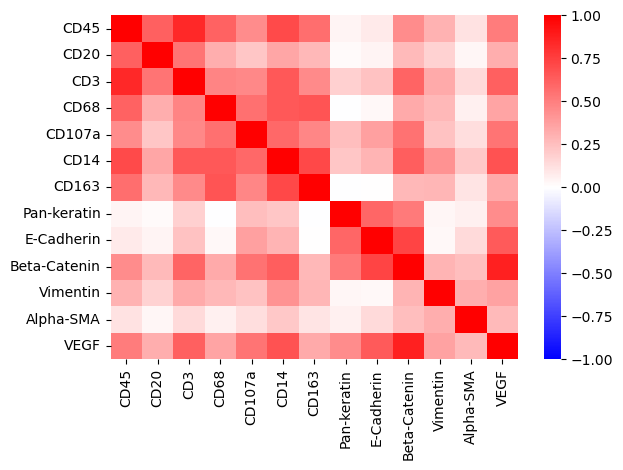

In [34]:
#plt.figure(figsize = (15,10))
sns.heatmap(corr,vmin=-1,vmax = 1,cmap = 'bwr')
plt.tight_layout()
#plt.savefig('figures/cell_corr_selected_p.pdf')

In [ ]:
corr_all = prot_table.corr()

<Figure size 1500x1000 with 0 Axes>

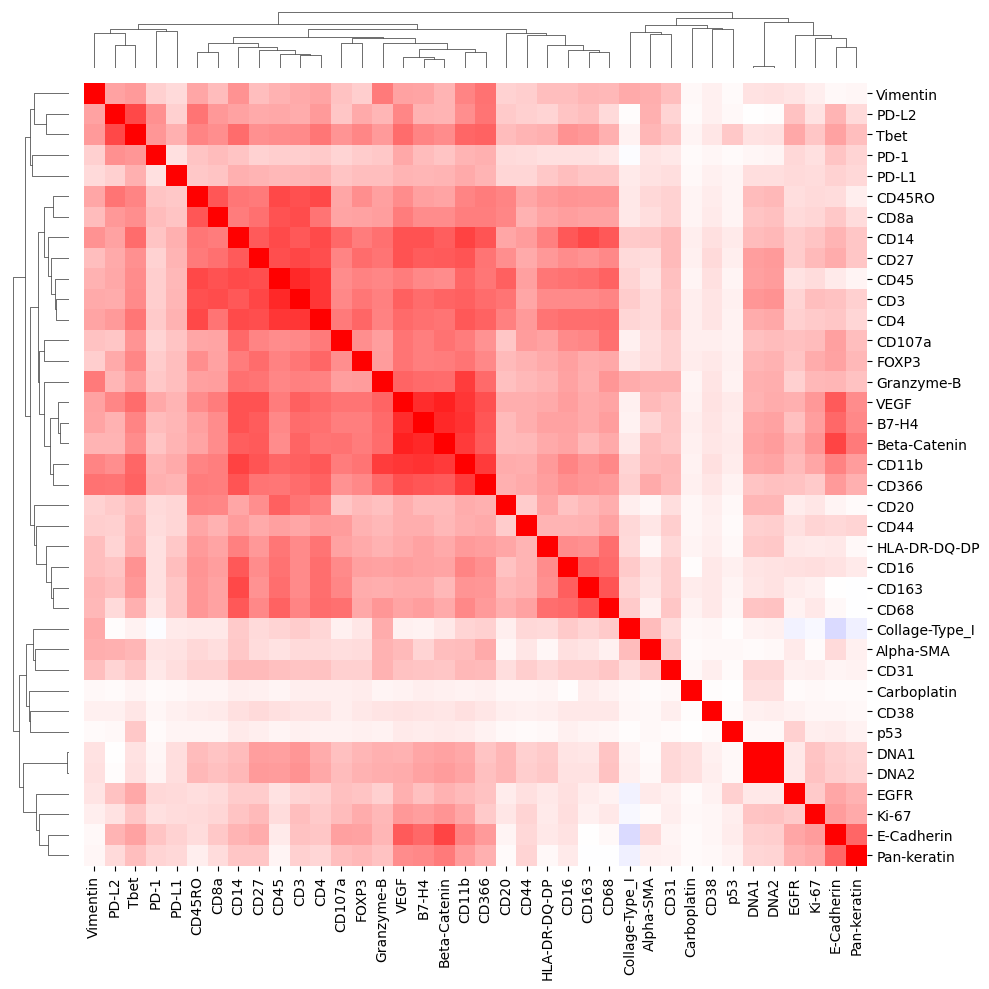

In [32]:
plt.figure(figsize = (15,10))
sns.clustermap(corr_all,vmin=-1,vmax = 1,cmap = 'bwr',dendrogram_ratio=0.07,cbar_pos= None)
plt.tight_layout()
#plt.savefig('figures/cell_corr_all_p.pdf')

In [30]:
!ls figures

1_smoothing_fuzzy.png  no_smoothing_mean.png  segm_expl_fuzzy.png
1_smoothing_mean.png   our_marker.png	      segm_expl_fuzzy.tiff
all_marker.png	       segm_expl_fuzzy	      segm_expl_mean.tiff


<Axes: ylabel='Count'>

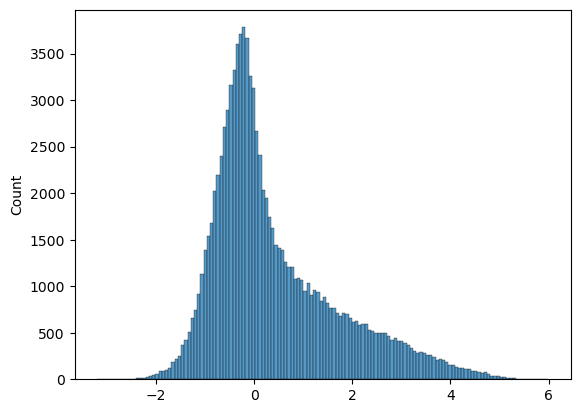

In [12]:
sns.histplot(z_score)

(array([229073., 155479., 135204., 122626., 109066.,  91997.,  74519.,
         60755.,  48733.,  39127.,  31058.,  25737.,  21379.,  18544.,
         16349.,  14267.,  12543.,  10787.,   9554.,  73203.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

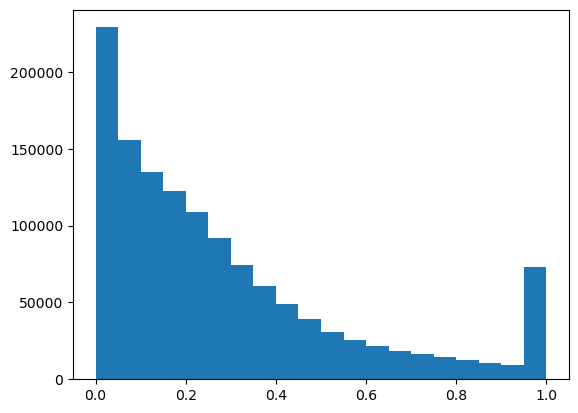

In [125]:
prot_table.loc[:,cost.index].shape, cost.shape
plt.hist(prot_table.loc[:,cost.index].values.ravel(),20)

In [92]:
prot_table.loc[:,cost.index].values>np.percentile(prot_table.loc[:,cost.index].values,95,axis = 0)

array([[ True,  True,  True, ...,  True, False,  True],
       [ True, False, False, ...,  True, False,  True],
       [ True,  True, False, ...,  True, False,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [118]:
prot_table.loc[:,cost.index]
for col in cost.index:
    d = prot_table[col].copy()
    d = d/np.percentile(d,95)
    d[d>1] = 1
    prot_table[col] = d


0        1.000000
1        1.000000
2        1.000000
3        0.302490
4        0.347998
           ...   
99995    0.115249
99996    0.025869
99997    0.093076
99998    0.115714
99999    0.135258
Name: VEGF, Length: 100000, dtype: float64

In [62]:
prot_table.loc[:,cost.index].loc[:,cost.Immune>0].sum(axis = 1)
-prot_table.loc[:,cost.index].loc[:,cost.Immune<0].sum(axis = 1)

0     -81.605676
1    -103.575303
2    -189.399710
3     -18.185756
4     -35.377771
5     -34.380570
6     -70.036828
7     -61.837399
8      -4.440141
9     -42.246380
10    -33.939044
11    -97.455523
12    -89.174737
13   -142.722814
14   -130.368114
15    -52.778233
16    -32.402235
17   -145.598848
18    -28.996172
19    -74.800450
dtype: float64

In [16]:
cost_tb.value_counts()
#prot_table.loc[:,cost.index]

Non-immune  Immune
-1           1        7
 1          -1        6
Name: count, dtype: int64

[]

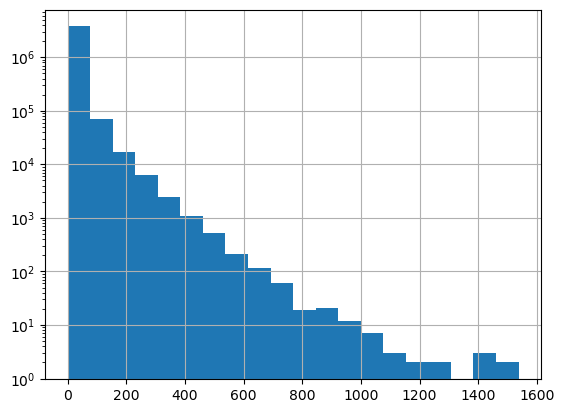

In [50]:
cell_table['Alpha-SMA'].hist(bins = 20)
plt.semilogy()

<Axes: >

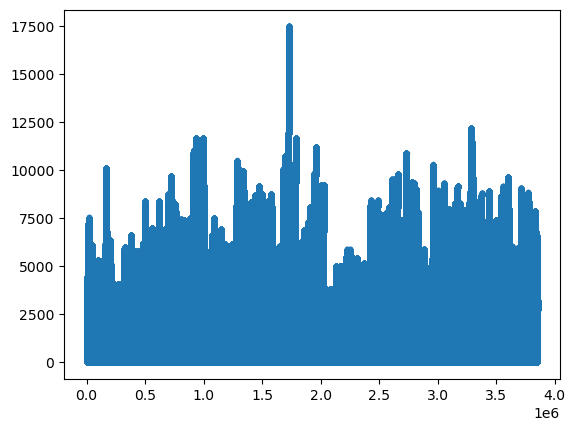

In [58]:
cell_table.label.plot(marker  = '.')

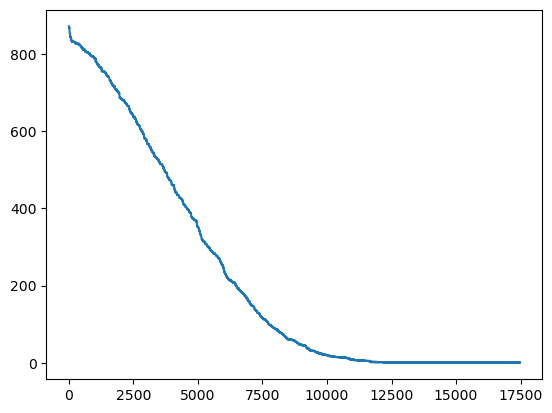

In [76]:
#sns.barplot(cell_table.label.value_counts())
x = cell_table.label.value_counts().index
y = cell_table.label.value_counts().values
plt.plot(x,y)

In [77]:
cell_table.label.value_counts()

label
1        871
3        871
4        871
5        871
2        871
        ... 
13939      1
13938      1
13937      1
13936      1
17468      1
Name: count, Length: 17468, dtype: int64